In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
print(df.shape)
print(df.sample(5))
print(df.isnull().sum())
print(df.describe())

(6607, 20)
      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
3774              9          74               Medium                 Low   
6600             12          98               Medium                 Low   
1603             15          93               Medium              Medium   
6395             25          91               Medium                 Low   
6356             33          78               Medium              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
3774                         No            6               69   
6600                        Yes            4               54   
1603                         No            5               86   
6395                         No            7               86   
6356                         No            9               72   

     Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
3774              Low             Yes                  3           

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


numerical cols: hours_studied, attendance,sleep_hours, previous_scores,tutoring_sessions, , physical_activity,exam_scores
(7)
categorical_cols:parental_involvement,Accesstoresources,extracurricular_activitites,motivationlevel,familyincome,teacherquality,schooltype,peerinfluence,learningdisabilities,parentaleducation,distancefromhome,gender(13)

In [40]:
print(df[df["Exam_Score"]>100])

      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1525             27          98                  Low              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
1525                        Yes            6               93   

     Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
1525              Low              No                  5          High   

     Teacher_Quality School_Type Peer_Influence  Physical_Activity  \
1525            High      Public       Positive                  3   

     Learning_Disabilities Parental_Education_Level Distance_from_Home  \
1525                    No              High School           Moderate   

      Gender  Exam_Score  
1525  Female         101  


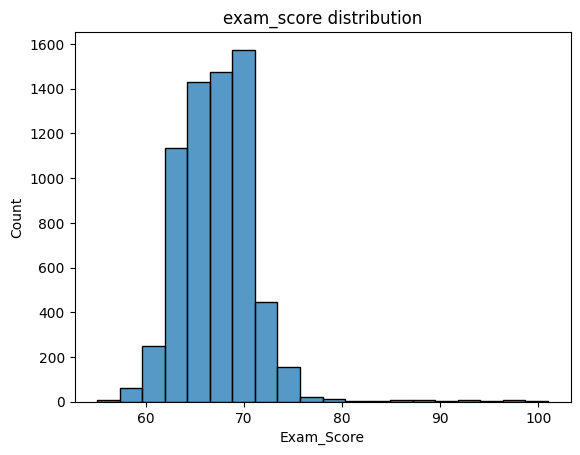

In [5]:
sns.histplot(df['Exam_Score'],bins =20)
plt.title("exam_score distribution")
plt.show()

In [6]:
df = df[df['Exam_Score']<=100]
df.shape

(6606, 20)

<Figure size 1200x800 with 0 Axes>

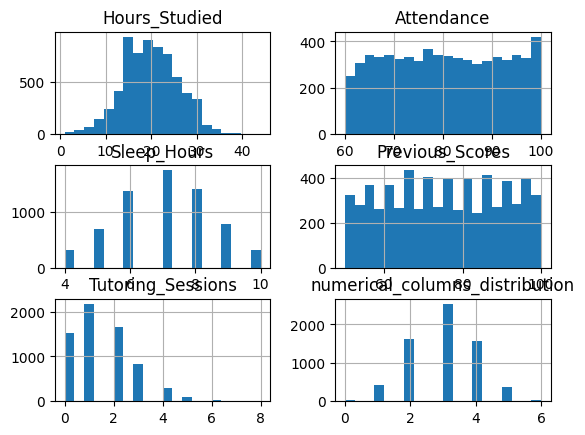

In [7]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
            'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
plt.figure(figsize=(12,8))
df[num_cols].hist(bins=20)
plt.title("numerical_columns_distribution")
plt.show()

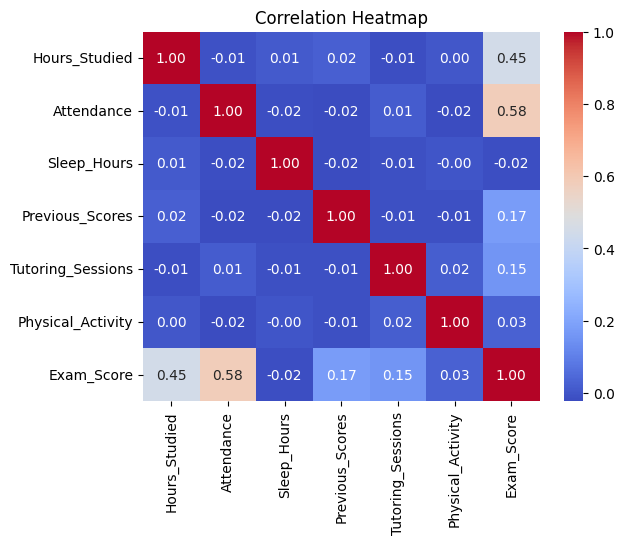

In [8]:
corr = df[num_cols + ['Exam_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

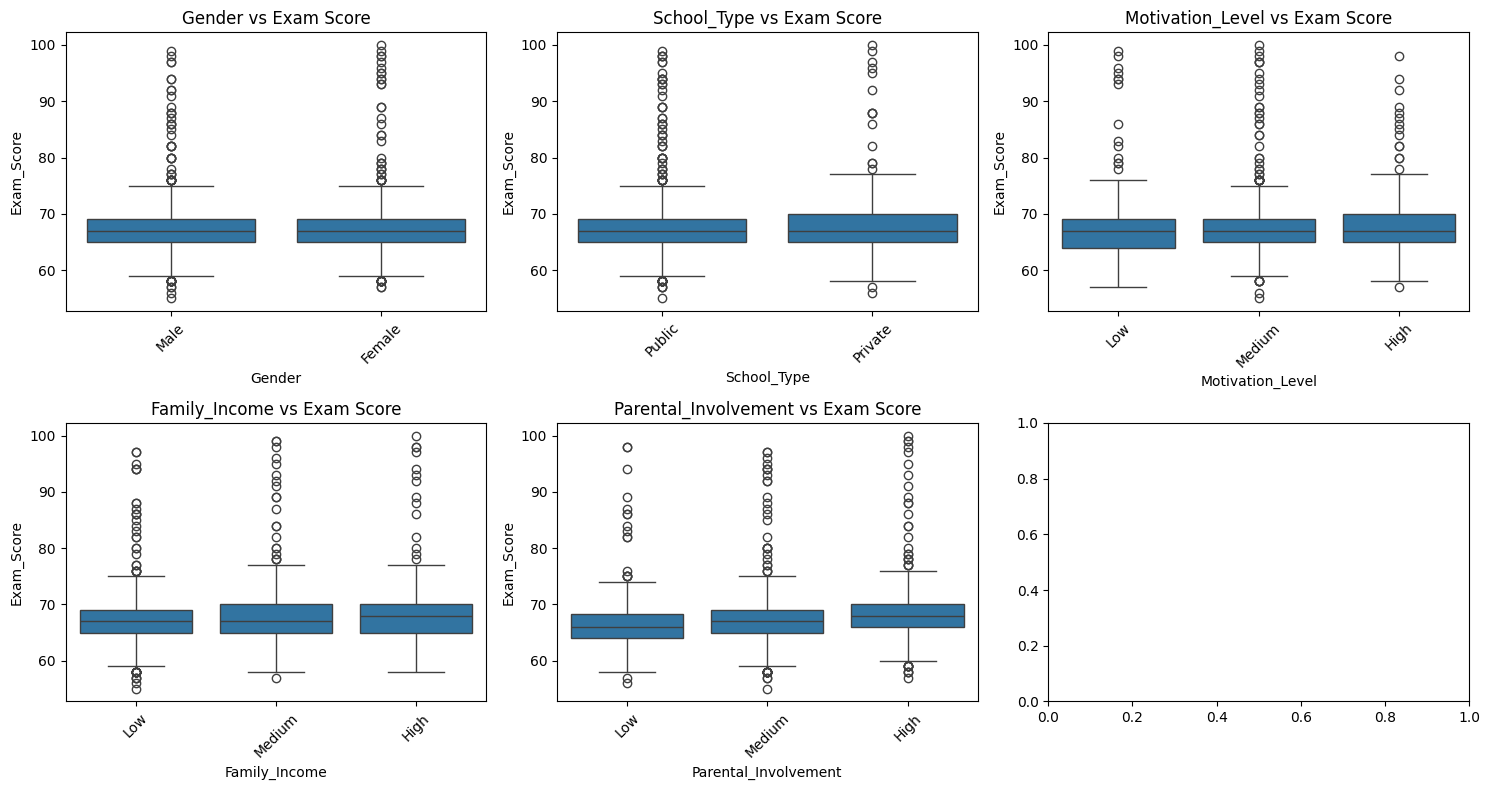

In [9]:
cat_cols = ['Gender', 'School_Type', 'Motivation_Level', 
            'Family_Income', 'Parental_Involvement']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='Exam_Score', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Exam Score')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

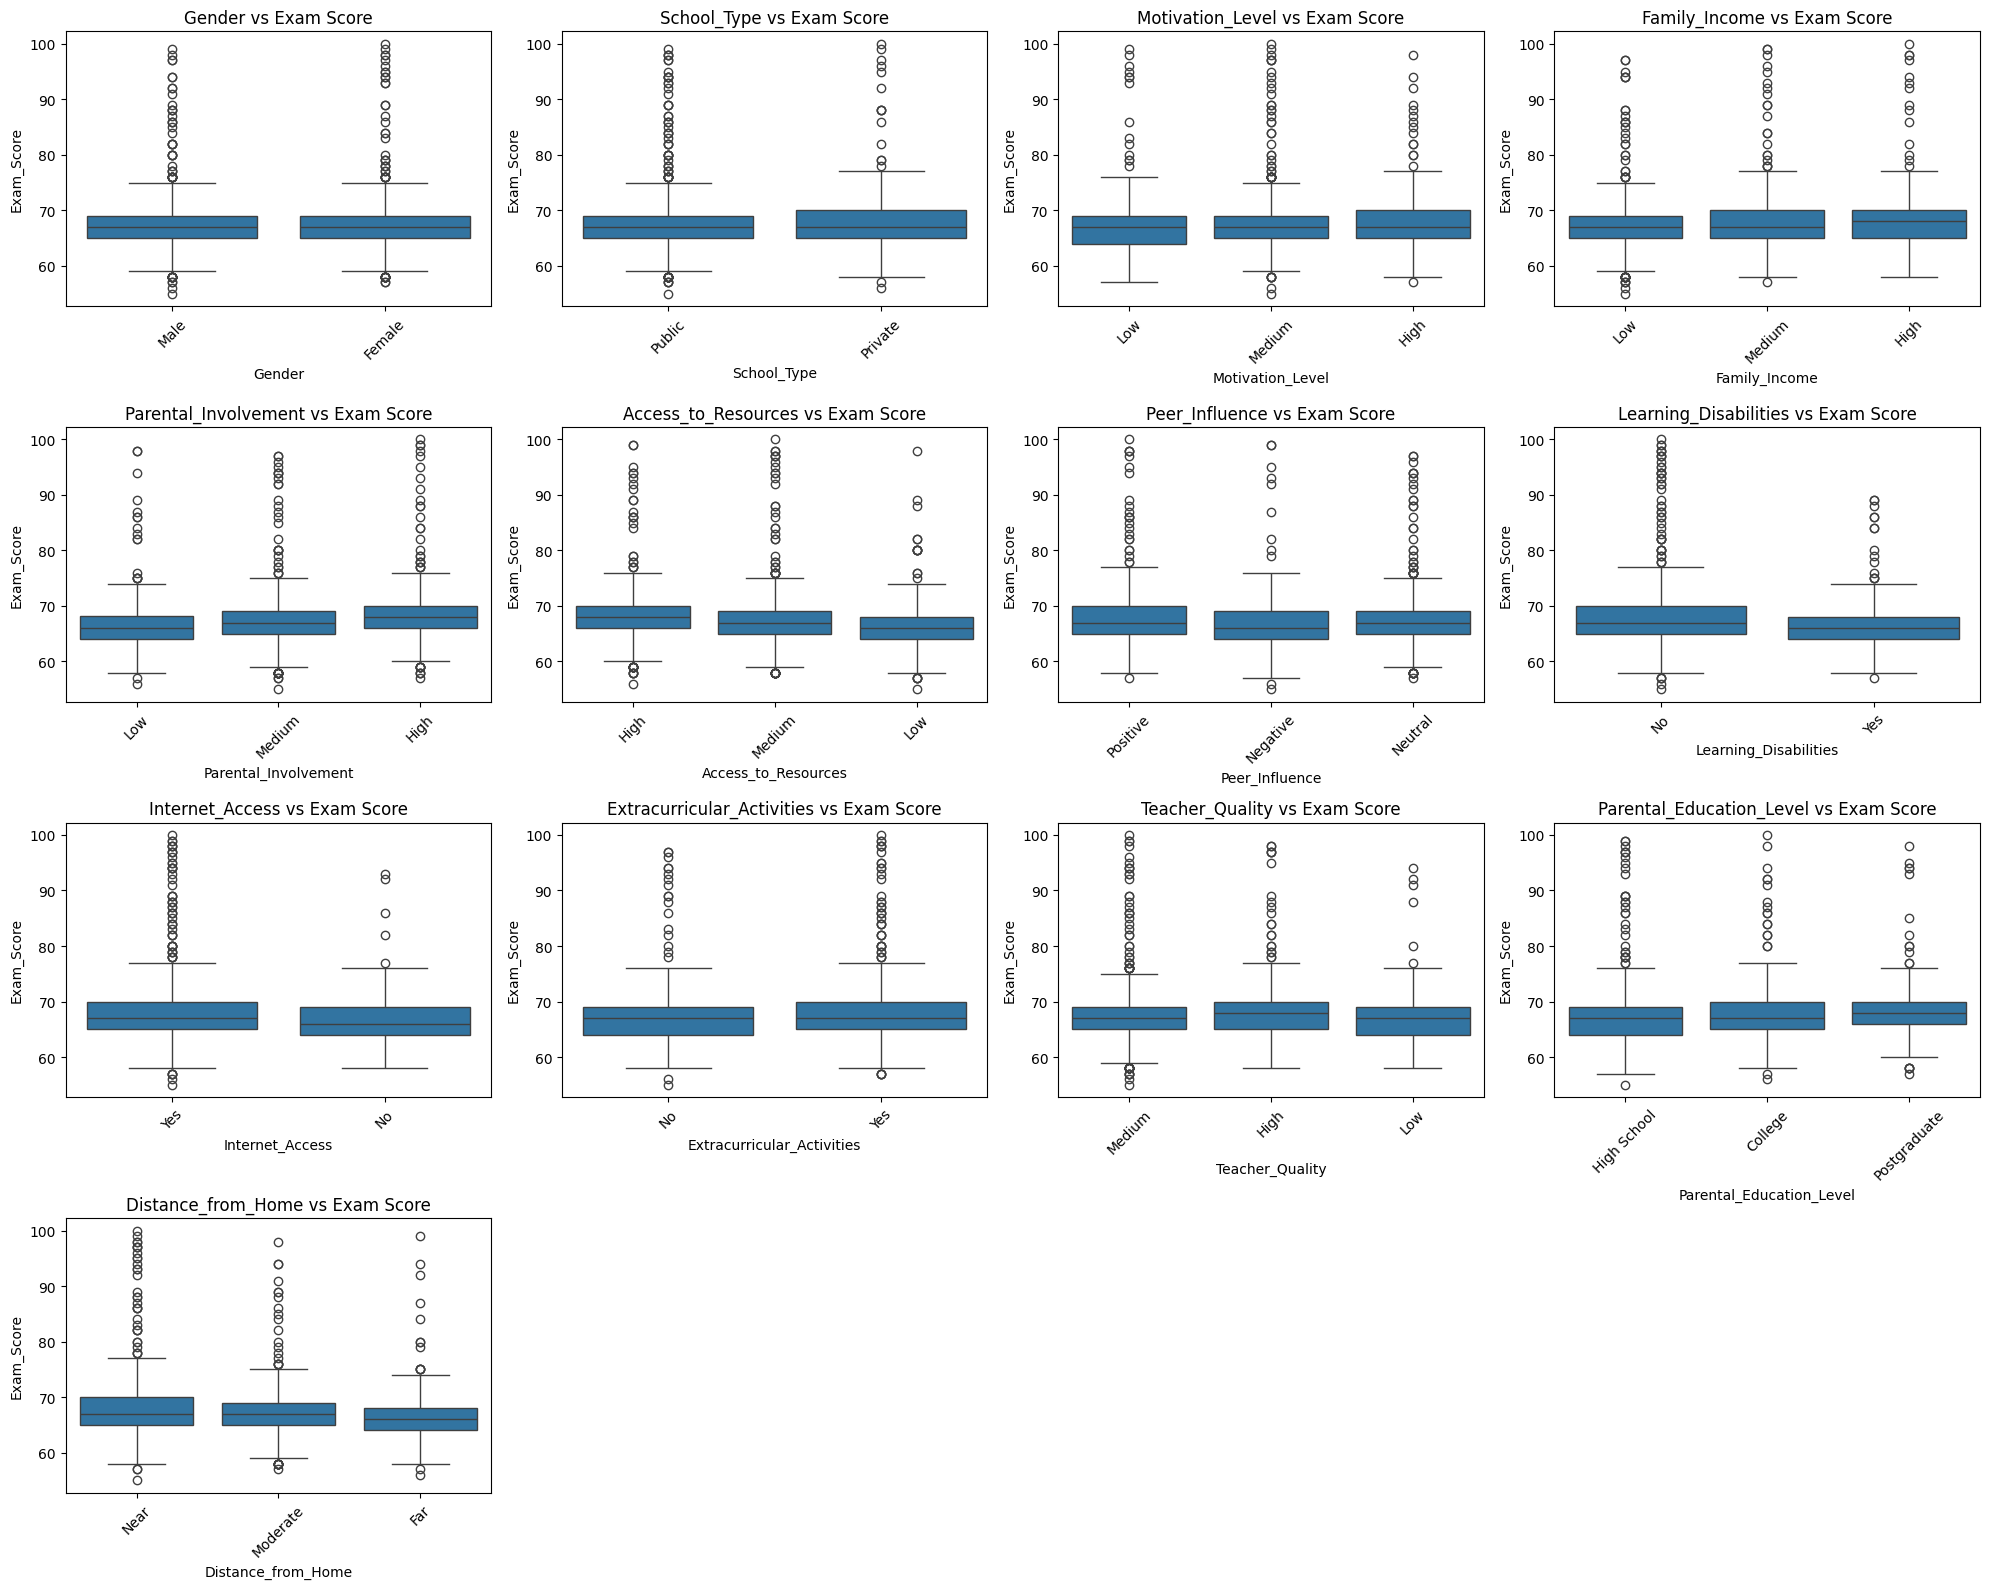

In [46]:
cat_cols = ['Gender', 'School_Type', 'Motivation_Level', 
            'Family_Income', 'Parental_Involvement',
            'Access_to_Resources', 'Peer_Influence',
            'Learning_Disabilities', 'Internet_Access',
            'Extracurricular_Activities', 'Teacher_Quality',
            'Parental_Education_Level', 'Distance_from_Home']


fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='Exam_Score', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Exam Score')
    axes[i].tick_params(axis='x', rotation=45)


for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

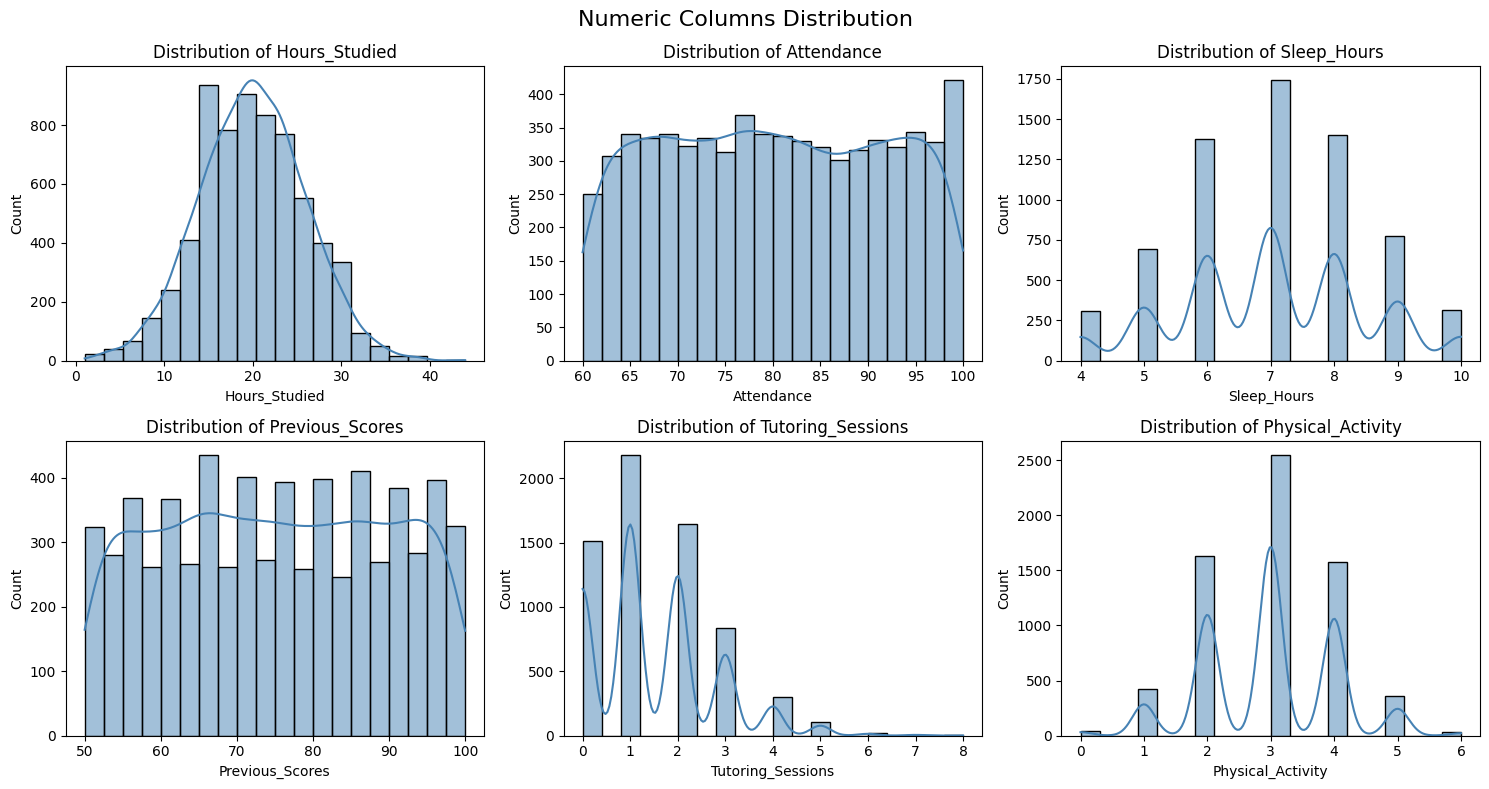

In [47]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
            'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle("Numeric Columns Distribution", fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\amans\AppData\Local\Temp\ipykernel_12712\2954286442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
C:\Users\amans\AppData\Local\Temp\ipykernel_12712\2954286442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
C:\Users\amans\AppData\Local\Temp\ipykernel_12712\2954286442.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
C:\Users\amans\AppData\Local\Temp\ipykernel_12712\2954286442.

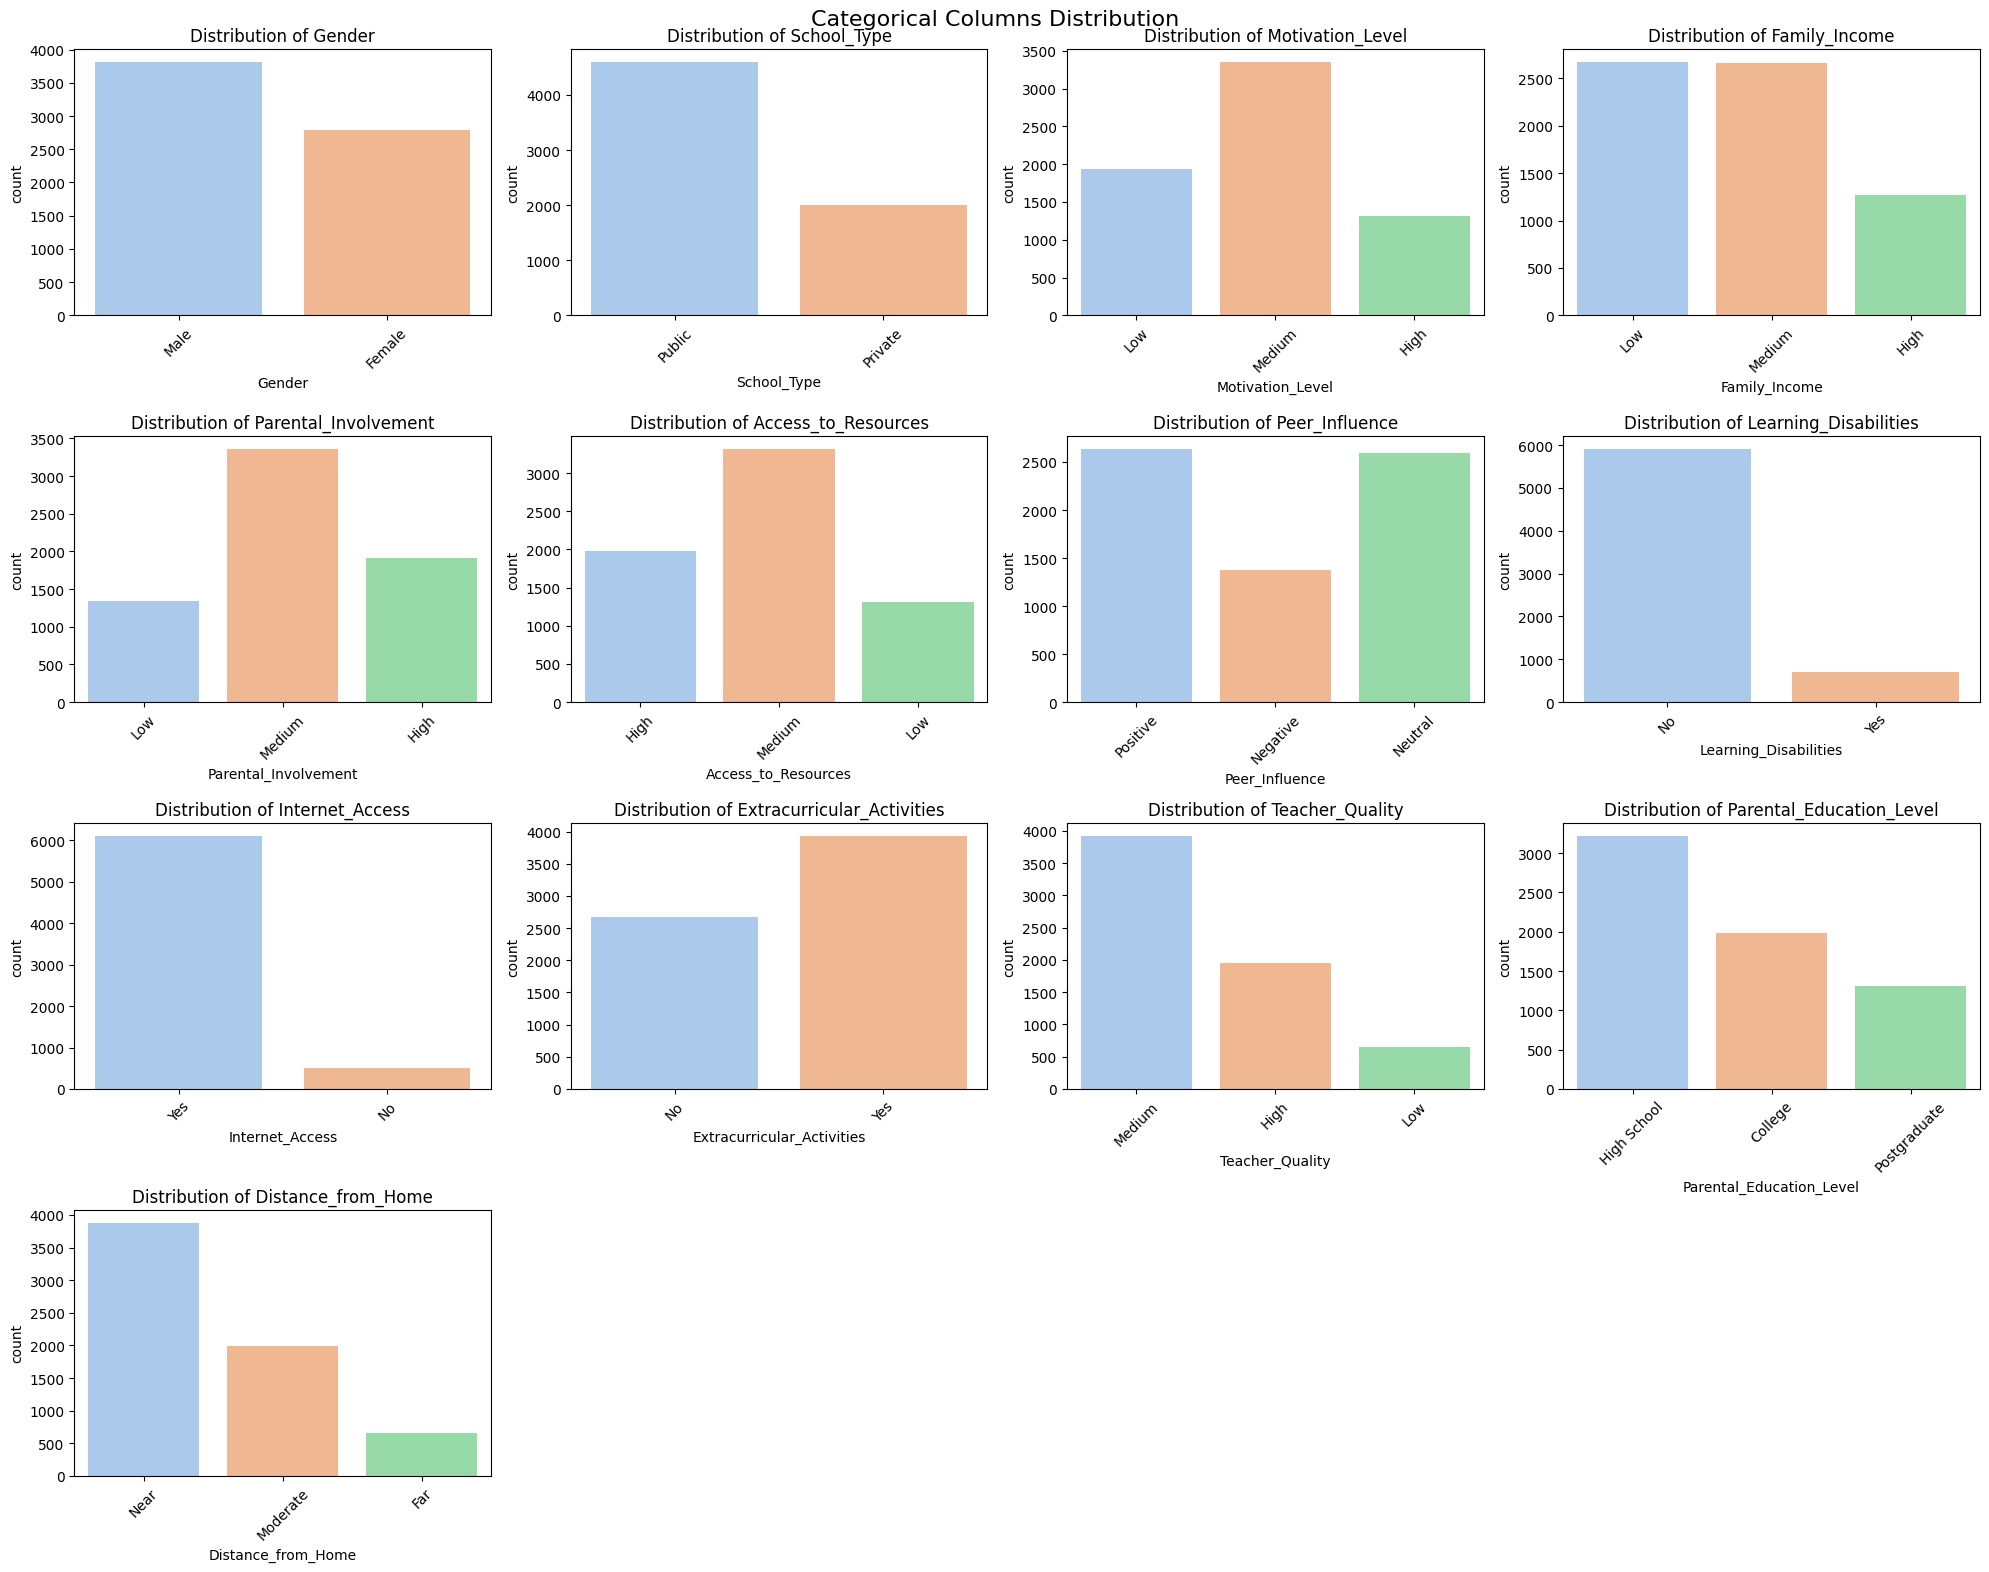

In [48]:
cat_cols = ['Gender', 'School_Type', 'Motivation_Level', 
            'Family_Income', 'Parental_Involvement',
            'Access_to_Resources', 'Peer_Influence',
            'Learning_Disabilities', 'Internet_Access',
            'Extracurricular_Activities', 'Teacher_Quality',
            'Parental_Education_Level', 'Distance_from_Home']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Columns Distribution", fontsize=16)
plt.tight_layout()
plt.show()

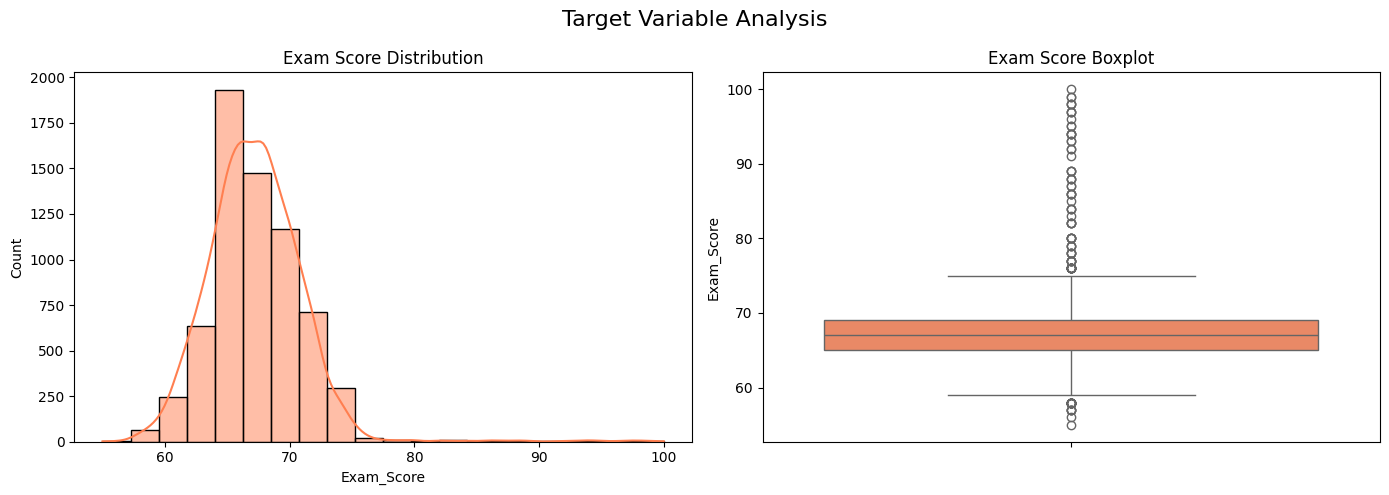

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df['Exam_Score'], bins=20, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Exam Score Distribution')

# Boxplot
sns.boxplot(y=df['Exam_Score'], ax=axes[1], color='coral')
axes[1].set_title('Exam Score Boxplot')

plt.suptitle("Target Variable Analysis", fontsize=16)
plt.tight_layout()
plt.show()

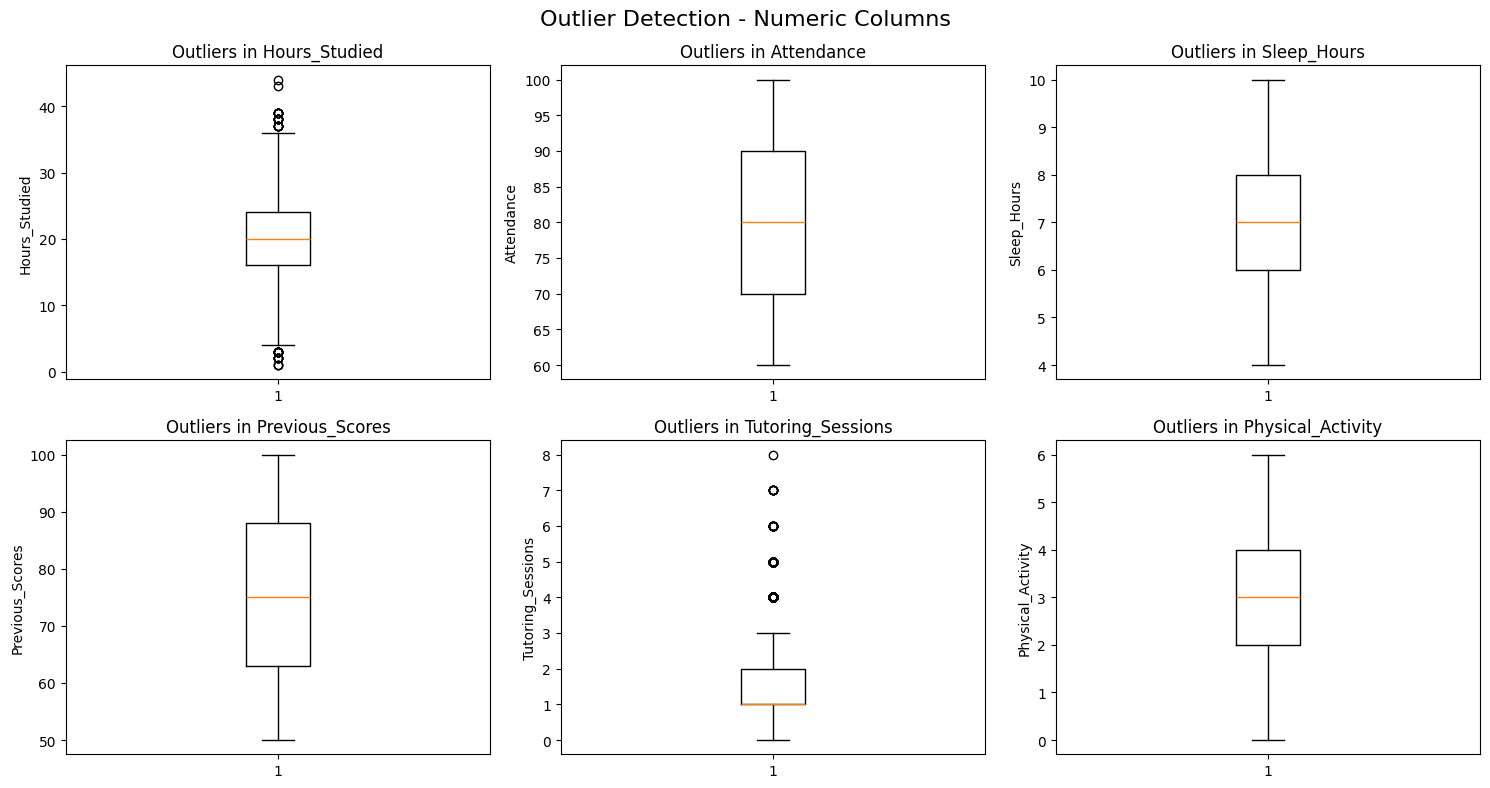

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Outliers in {col}')
    axes[i].set_ylabel(col)

plt.suptitle("Outlier Detection - Numeric Columns", fontsize=16)
plt.tight_layout()
plt.show()

In [51]:
# for col in num_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR
#     outliers = df[(df[col] < lower) | (df[col] > upper)]
#     print(f"{col}: {len(outliers)} outliers | Lower: {lower:.1f} | Upper: {upper:.1f}")

In [52]:
df['Hours_Studied'] = df['Hours_Studied'].clip(upper=36)


In [53]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [54]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours',
            'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

ordinal_cols = ['Parental_Involvement', 'Access_to_Resources',
                'Motivation_Level', 'Family_Income', 'Teacher_Quality',
                'Parental_Education_Level', 'Distance_from_Home',
                'Peer_Influence']

nominal_cols = ['Gender', 'School_Type', 'Extracurricular_Activities',
                'Internet_Access', 'Learning_Disabilities']

In [55]:
ordinal_orders = [
    ['Low', 'Medium', 'High'],                      
    ['Low', 'Medium', 'High'],                      
    ['Low', 'Medium', 'High'],                       
    ['Low', 'Medium', 'High'],                       
    ['Low', 'Medium', 'High'],                       
    ['High School', 'College', 'Postgraduate'],      
    ['Near', 'Moderate', 'Far'],                     
    ['Negative', 'Neutral', 'Positive'],             
]

In [56]:
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_orders))
])
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


In [57]:
preprocessor = ColumnTransformer([
    ('num',     num_pipeline,     num_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('nominal', nominal_pipeline, nominal_cols)
])
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [59]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [60]:
y_pred = pipeline.predict(X_test)

In [61]:
r2_score(y_test,y_pred)

0.8256806619193695

In [62]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(1.5183007300344393)

In [63]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,X,y,cv=20,scoring='r2'     
)

print("R² for each fold:", cv_scores.round(4))
print(f"Mean R²         : {cv_scores.mean():.4f}")
print(f"Std R²          : {cv_scores.std():.4f}")

R² for each fold: [0.6563 0.5601 0.6277 0.6681 0.8245 0.8463 0.8077 0.5638 0.6356 0.7133
 0.6968 0.8265 0.7923 0.5696 0.7473 0.9159 0.9872 0.9872 0.8194 0.6688]
Mean R²         : 0.7457
Std R²          : 0.1280


In [64]:

cols_to_drop = ['Gender', 'School_Type', 'Internet_Access', 
                'Sleep_Hours', 'Physical_Activity', 'Distance_from_Home']

df_reduced = df.drop(columns=cols_to_drop)

print("Original shape:", df.shape)
print("Reduced shape :", df_reduced.shape)
print("\nRemaining columns:", df_reduced.columns.tolist())

Original shape: (6606, 20)
Reduced shape : (6606, 14)

Remaining columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores', 'Motivation_Level', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Exam_Score']


In [65]:

X_reduced = df_reduced.iloc[:, :-1]
y_reduced  = df_reduced.iloc[:, -1]

num_cols_r = ['Hours_Studied', 'Attendance', 
              'Previous_Scores', 'Tutoring_Sessions']

ordinal_cols_r = ['Parental_Involvement', 'Access_to_Resources',
                  'Motivation_Level', 'Family_Income', 'Teacher_Quality',
                  'Parental_Education_Level', 'Peer_Influence']

nominal_cols_r = ['Extracurricular_Activities', 'Learning_Disabilities']

In [66]:

ordinal_orders_r = [
    ['Low', 'Medium', 'High'],                   
    ['Low', 'Medium', 'High'],                   
    ['Low', 'Medium', 'High'],                  
    ['Low', 'Medium', 'High'],                   
    ['Low', 'Medium', 'High'],                 
    ['High School', 'College', 'Postgraduate'],  
    ['Negative', 'Neutral', 'Positive'],         
]


num_pipeline_r = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

ordinal_pipeline_r = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_orders_r))
])

nominal_pipeline_r = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_r = ColumnTransformer([
    ('num',     num_pipeline_r,     num_cols_r),
    ('ordinal', ordinal_pipeline_r, ordinal_cols_r),
    ('nominal', nominal_pipeline_r, nominal_cols_r)
])

# Full pipeline
full_pipeline_r = Pipeline([
    ('preprocessor', preprocessor_r),
    ('model', Ridge())
])

In [67]:
from sklearn.model_selection import cross_val_score
import numpy as np
cv_original = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
cv_reduced = cross_val_score(full_pipeline_r, X_reduced, y_reduced, cv=5, scoring='r2')

print("Original Model (all features):")
print(f"  Scores : {cv_original.round(4)}")
print(f"  Mean R²: {cv_original.mean():.4f}")
print(f"  Std R² : {cv_original.std():.4f}")

print("\nReduced Model (dropped weak features):")
print(f"  Scores : {cv_reduced.round(4)}")
print(f"  Mean R²: {cv_reduced.mean():.4f}")
print(f"  Std R² : {cv_reduced.std():.4f}")

Original Model (all features):
  Scores : [0.6256 0.7449 0.7095 0.7337 0.8401]
  Mean R²: 0.7308
  Std R² : 0.0688

Reduced Model (dropped weak features):
  Scores : [0.6149 0.7368 0.6961 0.7204 0.8205]
  Mean R²: 0.7177
  Std R² : 0.0663


In [68]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(),
    'Lasso Regression'    : Lasso(),
    'Decision Tree'       : DecisionTreeRegressor(random_state=42),
    'Random Forest'       : RandomForestRegressor(random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(random_state=42),
    'KNN'                 : KNeighborsRegressor()
}

In [69]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
  
    r2_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    
    rmse_scores = -cross_val_score(pipeline, X, y, cv=5, 
                                   scoring='neg_root_mean_squared_error')
    
    results.append({
        'Model'    : name,
        'Mean R²'  : round(r2_scores.mean(), 4),
        'Std R²'   : round(r2_scores.std(), 4),
        'Mean RMSE': round(rmse_scores.mean(), 4),
        'Std RMSE' : round(rmse_scores.std(), 4)
    })
results_df = pd.DataFrame(results).sort_values('Mean R²', ascending=False)
print("\n", results_df.to_string(index=False))


             Model  Mean R²  Std R²  Mean RMSE  Std RMSE
 Ridge Regression   0.7308  0.0688     1.9924    0.2912
Linear Regression   0.7307  0.0688     1.9924    0.2912
Gradient Boosting   0.6938  0.0648     2.1303    0.2585
    Random Forest   0.6419  0.0568     2.3088    0.2168
              KNN   0.5571  0.0518     2.5706    0.1850
 Lasso Regression   0.4084  0.0309     2.9740    0.1215
    Decision Tree   0.2434  0.0339     3.3627    0.1027


In [70]:
from sklearn.model_selection import GridSearchCV
ridge_params = {
    'model__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 
                     10.0, 50.0, 100.0, 500.0, 1000.0]
}

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='r2',
    verbose=1
)

ridge_grid.fit(X, y)

print(f"\nBest Alpha    : {ridge_grid.best_params_}")
print(f"Best R² Score : {ridge_grid.best_score_:.4f}")
from sklearn.model_selection import RandomizedSearchCV

gb_params = {
    'model__n_estimators'  : [100, 200, 300],
    'model__learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'model__max_depth'     : [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10],
    'model__subsample'     : [0.8, 0.9, 1.0]
}

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_random = RandomizedSearchCV(
    gb_pipeline,
    gb_params,
    n_iter=20,        
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=1
)

gb_random.fit(X, y)

print(f"\nBest Params   : {gb_random.best_params_}")
print(f"Best R² Score : {gb_random.best_score_:.4f}")
rf_params = {
    'model__n_estimators'  : [100, 200, 300],
    'model__max_depth'     : [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features'  : ['sqrt', 'log2', None]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_random = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=1
)

rf_random.fit(X, y)

print(f"\nBest Params   : {rf_random.best_params_}")
print(f"Best R² Score : {rf_random.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Alpha    : {'model__alpha': 5.0}
Best R² Score : 0.7308
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params   : {'model__subsample': 0.9, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 2, 'model__learning_rate': 0.2}
Best R² Score : 0.7051
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params   : {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_features': None, 'model__max_depth': 20}
Best R² Score : 0.6479
